<a href="https://colab.research.google.com/github/rajeshwar-sopho/collab-notebooks/blob/main/ai_engineering/multimodal_embedding.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# =============================================================
# Multimodal Embeddings with CLIP on Google Colab
# =============================================================
# CLIP (Contrastive Language-Image Pretraining) by OpenAI maps
# both text and images into the SAME embedding space, so you can
# directly compare them with cosine similarity.
#
# Run each section as a separate Colab cell.


# ── CELL 1: Install dependencies ─────────────────────────────
!pip install -q transformers torch Pillow

In [ ]:
# ── CELL 2: Upload the fisherman image ───────────────────────
# Upload the fisherman.png file to Colab.
# Option A — drag it into the Colab file panel on the left.
# Option B — use this upload widget:

from google.colab import files
import shutil

uploaded = files.upload()  # pick fisherman.png from your computer
IMAGE_PATH = list(uploaded.keys())[0]
print(f"Uploaded: {IMAGE_PATH}")

Saving fisherman.png to fisherman (1).png
Uploaded: fisherman (1).png


In [ ]:
# ── CELL 3: Load CLIP model and processor ────────────────────
from transformers import CLIPModel, CLIPProcessor, CLIPTokenizer
from PIL import Image
import torch
import numpy as np

MODEL_ID = "openai/clip-vit-base-patch32"   # ungated, ~600 MB

print("Loading CLIP model...")
model     = CLIPModel.from_pretrained(MODEL_ID)
processor = CLIPProcessor.from_pretrained(MODEL_ID)
tokenizer = CLIPTokenizer.from_pretrained(MODEL_ID)
print("Model loaded!")

Loading CLIP model...


Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

CLIPModel LOAD REPORT from: openai/clip-vit-base-patch32
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
text_model.embeddings.position_ids   | UNEXPECTED |  | 
vision_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Model loaded!


Text:  "a fisherman"
Image: fisherman (1).png  (600x700 px)


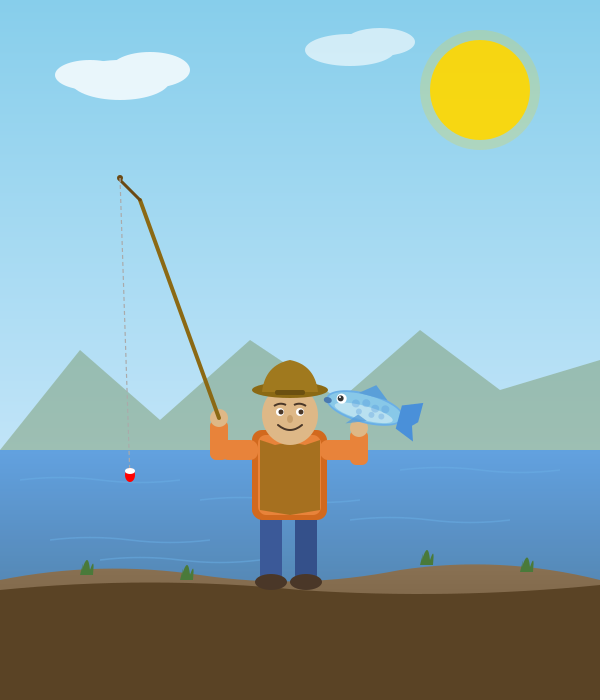

In [ ]:
# ── CELL 4: Prepare inputs ───────────────────────────────────
# The text we want to embed
text = "a fisherman"

# The image we want to embed
image = Image.open(IMAGE_PATH).convert("RGB")

# Let's see what we're working with
print(f"Text:  \"{text}\"")
print(f"Image: {IMAGE_PATH}  ({image.size[0]}x{image.size[1]} px)")
image  # displays the image inline in Colab

In [ ]:
# ── CELL 5: Understand how CLIP preprocesses inputs ─────────
# ----- TEXT PREPROCESSING -----
# CLIP tokenizes text similarly to GPT-2 (BPE tokenizer).
# Special tokens: <|startoftext|> and <|endoftext|>
# The text is padded/truncated to a fixed context length of 77 tokens.

text_tokens = tokenizer(text, return_tensors="pt")
token_ids   = text_tokens["input_ids"][0].tolist()

print("=" * 60)
print("📝 TEXT TOKENIZATION")
print("=" * 60)
print(f"Raw text:     \"{text}\"")
print(f"Token count:  {len(token_ids)}  (padded to context_length=77)")
print()
print("Token-by-token breakdown:")
print("-" * 40)
for tid in token_ids:
    decoded = tokenizer.decode([tid])
    print(f"  {tid:>6d}  →  {repr(decoded)}")
print("-" * 40)

# ----- IMAGE PREPROCESSING -----
# CLIP resizes the image to 224x224 and normalizes pixel values
# using ImageNet mean/std. The image is split into 7x7 = 49 patches
# of 32x32 pixels each (for ViT-B/32), plus 1 [CLS] token = 50 tokens.
image_inputs = processor(images=image)
pixel_values = torch.tensor(np.array(image_inputs["pixel_values"]))

print()
print("=" * 60)
print("🖼️  IMAGE PREPROCESSING")
print("=" * 60)
print(f"Original size:      {image.size[0]}x{image.size[1]} px")
print(f"After preprocessing: {pixel_values.shape}")
print(f"  → Batch size:      {pixel_values.shape[0]}")
print(f"  → Channels (RGB):  {pixel_values.shape[1]}")
print(f"  → Height:          {pixel_values.shape[2]} px  (resized)")
print(f"  → Width:           {pixel_values.shape[3]} px  (resized)")
print(f"Pixel value range:   [{pixel_values.min():.3f}, {pixel_values.max():.3f}]")
print(f"  (normalized with ImageNet mean & std)")
print()
print("Patch breakdown (ViT-B/32):")
print(f"  → Patch size:      32 x 32 pixels")
print(f"  → Grid:            7 x 7 = 49 patches")
print(f"  → Total tokens:    49 patches + 1 [CLS] = 50 tokens")

📝 TEXT TOKENIZATION
Raw text:     "a fisherman"
Token count:  4  (padded to context_length=77)

Token-by-token breakdown:
----------------------------------------
   49406  →  '<|startoftext|>'
     320  →  'a'
   25055  →  'fisherman'
   49407  →  '<|endoftext|>'
----------------------------------------

🖼️  IMAGE PREPROCESSING
Original size:      600x700 px
After preprocessing: torch.Size([1, 3, 224, 224])
  → Batch size:      1
  → Channels (RGB):  3
  → Height:          224 px  (resized)
  → Width:           224 px  (resized)
Pixel value range:   [-1.752, 2.146]
  (normalized with ImageNet mean & std)

Patch breakdown (ViT-B/32):
  → Patch size:      32 x 32 pixels
  → Grid:            7 x 7 = 49 patches
  → Total tokens:    49 patches + 1 [CLS] = 50 tokens


In [ ]:
# ── CELL 6: Generate embeddings ──────────────────────────────
# CLIP has two encoders:
#   1. Text encoder  — transforms token IDs → 512-dim vector
#   2. Image encoder — transforms pixel patches → 512-dim vector
# Both output vectors live in the SAME space, so cosine similarity
# between a text vector and an image vector is meaningful.

with torch.no_grad():
    # Encode the text
    text_inputs   = tokenizer(text, return_tensors="pt", padding=True)
    text_outputs  = model.get_text_features(**text_inputs)

    # Encode the image
    image_inputs  = processor(images=image)
    pixel_vals = torch.FloatTensor(np.array(image_inputs["pixel_values"]))
    image_outputs = model.get_image_features(pixel_values=pixel_vals)

# Normalize to unit vectors (standard practice for cosine similarity)
text_embedding  = text_outputs.pooler_output.detach()
text_embedding  = text_embedding / text_embedding.norm(dim=-1, keepdim=True)

image_embedding = image_outputs.pooler_output.detach()
image_embedding = image_embedding / image_embedding.norm(dim=-1, keepdim=True)

print("=" * 60)
print("🔢 EMBEDDING RESULTS")
print("=" * 60)
print(f"Text embedding shape:  {text_embedding.shape}   → {text_embedding.shape[-1]}-dimensional vector")
print(f"Image embedding shape: {image_embedding.shape}  → {image_embedding.shape[-1]}-dimensional vector")
print()
print(f"Text embedding  (first 10 dims):  {text_embedding[0, :10].tolist()}")
print(f"Image embedding (first 10 dims):  {image_embedding[0, :10].tolist()}")

🔢 EMBEDDING RESULTS
Text embedding shape:  torch.Size([1, 512])   → 512-dimensional vector
Image embedding shape: torch.Size([1, 512])  → 512-dimensional vector

Text embedding  (first 10 dims):  [-0.025120997801423073, -0.028464924544095993, -0.014261399395763874, -0.018945174291729927, 0.014836658723652363, -0.04658529907464981, -0.019168522208929062, -0.09097694605588913, -0.024328775703907013, 0.01744132488965988]
Image embedding (first 10 dims):  [0.0005375543842092156, -0.008679934777319431, 0.03267460688948631, -0.029479026794433594, 0.012654231861233711, -0.047116171568632126, -0.021969955414533615, 0.02254815585911274, -0.02107284963130951, 0.01765028014779091]


In [ ]:
# ── CELL 7: Compute similarity ───────────────────────────────
import torch.nn.functional as F

# Cosine similarity (both are already normalized, so dot product = cosine sim)
cosine_sim = F.cosine_similarity(text_embedding, image_embedding).item()

# CLIP also provides a built-in way via logits (includes learned temperature)
inputs = processor(text=[text], images=image, return_tensors="pt", padding=True)
with torch.no_grad():
    outputs = model(**inputs)
    logits_per_image = outputs.logits_per_image  # image-text similarity score

print("=" * 60)
print("📊 SIMILARITY BETWEEN TEXT AND IMAGE")
print("=" * 60)
print(f"Text:  \"{text}\"")
print(f"Image: {IMAGE_PATH}")
print()
print(f"Cosine similarity:     {cosine_sim:.4f}   (range: -1 to 1)")
print(f"CLIP logit score:      {logits_per_image.item():.2f}  (higher = more similar)")
print()
if cosine_sim > 0.25:
    print(f"✅ High similarity! The model sees a strong match between the text and image.")
elif cosine_sim > 0.15:
    print(f"🟡 Moderate similarity. The model sees some connection.")
else:
    print(f"🔴 Low similarity. The model doesn't see a strong match.")

📊 SIMILARITY BETWEEN TEXT AND IMAGE
Text:  "a fisherman"
Image: fisherman (1).png

Cosine similarity:     0.2912   (range: -1 to 1)
CLIP logit score:      29.12  (higher = more similar)

✅ High similarity! The model sees a strong match between the text and image.


In [ ]:
# ── CELL 8: Compare against other texts to see contrast ──────
# This shows WHY multimodal embeddings are powerful — the same
# image is closer to relevant text and farther from irrelevant text.

comparison_texts = [
    "a fisherman",
    "a man holding a fishing rod and a fish",
    "fishing by a river",
    "a person cooking in a kitchen",
    "a red sports car on a highway",
    "a cat sleeping on a sofa",
    "abstract mathematics equation",
]

print("=" * 60)
print("📊 IMAGE vs MULTIPLE TEXTS — Cosine Similarities")
print("=" * 60)
print(f"Image: {IMAGE_PATH}\n")

results = []
with torch.no_grad():
    for t in comparison_texts:
        t_inputs = tokenizer(t, return_tensors="pt", padding=True)
        t_feat   = model.get_text_features(**t_inputs).pooler_output.detach()
        t_feat   = t_feat / t_feat.norm(dim=-1, keepdim=True)
        sim      = F.cosine_similarity(t_feat, image_embedding).item()
        results.append((t, sim))

# Sort by similarity (highest first)
results.sort(key=lambda x: x[1], reverse=True)

for text_label, sim in results:
    bar = "█" * int(sim * 80)
    print(f"  {sim:+.4f}  {bar}  \"{text_label}\"")

print()
print("Notice how fishing-related texts score much higher than")
print("unrelated concepts — that's multimodal embeddings at work!")

📊 IMAGE vs MULTIPLE TEXTS — Cosine Similarities
Image: fisherman (1).png

  +0.3316  ██████████████████████████  "a man holding a fishing rod and a fish"
  +0.2912  ███████████████████████  "a fisherman"
  +0.2904  ███████████████████████  "fishing by a river"
  +0.1915  ███████████████  "abstract mathematics equation"
  +0.1830  ██████████████  "a person cooking in a kitchen"
  +0.1154  █████████  "a red sports car on a highway"
  +0.1041  ████████  "a cat sleeping on a sofa"

Notice how fishing-related texts score much higher than
unrelated concepts — that's multimodal embeddings at work!


/tmp/ipykernel_5972/908077523.py:51: UserWarning: Glyph 128444 (\N{FRAME WITH PICTURE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_5972/908077523.py:52: UserWarning: Glyph 128444 (\N{FRAME WITH PICTURE}) missing from font(s) DejaVu Sans.
  plt.savefig("embedding_space.png", dpi=150, bbox_inches="tight")
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128444 (\N{FRAME WITH PICTURE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


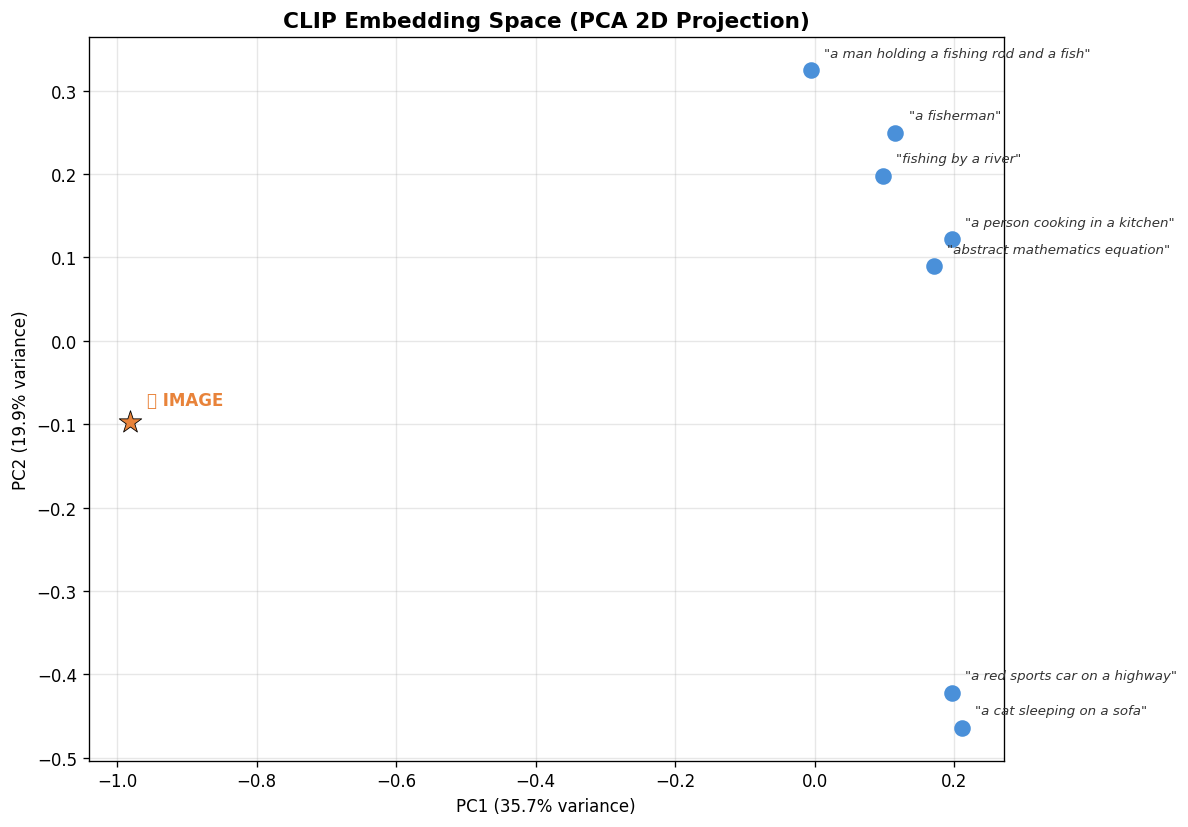

Saved: embedding_space.png


In [ ]:
# ── CELL 9: Visualize the embedding space (2D projection) ────
# We project the 512-dim vectors down to 2D using PCA so you
# can SEE how text and image embeddings cluster together.

import numpy as np
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams["figure.dpi"] = 120

# Collect all embeddings
all_texts  = comparison_texts
all_labels = comparison_texts + ["🖼️ IMAGE"]

with torch.no_grad():
    all_text_embs = []
    for t in all_texts:
        t_inputs = tokenizer(t, return_tensors="pt", padding=True)
        t_feat   = model.get_text_features(**t_inputs).pooler_output.detach()
        t_feat   = t_feat / t_feat.norm(dim=-1, keepdim=True)
        all_text_embs.append(t_feat.squeeze().numpy())

all_embs = np.vstack(all_text_embs + [image_embedding.squeeze().numpy()])

# PCA to 2D
pca = PCA(n_components=2)
coords = pca.fit_transform(all_embs)

# Plot
fig, ax = plt.subplots(figsize=(10, 7))

# Text points
for i, label in enumerate(all_texts):
    ax.scatter(coords[i, 0], coords[i, 1], s=80, c="#4A90D9", zorder=3)
    ax.annotate(f'"{label}"', (coords[i, 0], coords[i, 1]),
                textcoords="offset points", xytext=(8, 8),
                fontsize=8, color="#333", style="italic")

# Image point (larger, different color)
img_idx = len(all_texts)
ax.scatter(coords[img_idx, 0], coords[img_idx, 1], s=200, c="#E8833A",
           marker="*", zorder=4, edgecolors="black", linewidths=0.5)
ax.annotate("🖼️ IMAGE", (coords[img_idx, 0], coords[img_idx, 1]),
            textcoords="offset points", xytext=(10, 10),
            fontsize=10, fontweight="bold", color="#E8833A")

ax.set_title("CLIP Embedding Space (PCA 2D Projection)", fontsize=13, fontweight="bold")
ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)")
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("embedding_space.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: embedding_space.png")

Select one or more images (.png or .webp)...


Saving an-indian-fisherman-with-a-basket-is-fishing-by-net-near-the-fishing-BR4ET0.jpg to an-indian-fisherman-with-a-basket-is-fishing-by-net-near-the-fishing-BR4ET0.jpg
Saving fisherman-fishing-boat_88114-439.avif to fisherman-fishing-boat_88114-439.avif
Saving life-of-a-fisherman-vertical-corrected.webp to life-of-a-fisherman-vertical-corrected.webp
Saving WF1412200_20211209_KEN_Rolopio_22.jpg to WF1412200_20211209_KEN_Rolopio_22.jpg
  ✅ Embedded: an-indian-fisherman-with-a-basket-is-fishing-by-net-near-the-fishing-BR4ET0.jpg
  ✅ Embedded: fisherman-fishing-boat_88114-439.avif
  ✅ Embedded: life-of-a-fisherman-vertical-corrected.webp
  ✅ Embedded: WF1412200_20211209_KEN_Rolopio_22.jpg


/tmp/ipykernel_5972/529361420.py:89: UserWarning: Glyph 128444 (\N{FRAME WITH PICTURE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_5972/529361420.py:90: UserWarning: Glyph 128444 (\N{FRAME WITH PICTURE}) missing from font(s) DejaVu Sans.
  plt.savefig("embedding_space_multi.png", dpi=150, bbox_inches="tight")
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128444 (\N{FRAME WITH PICTURE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


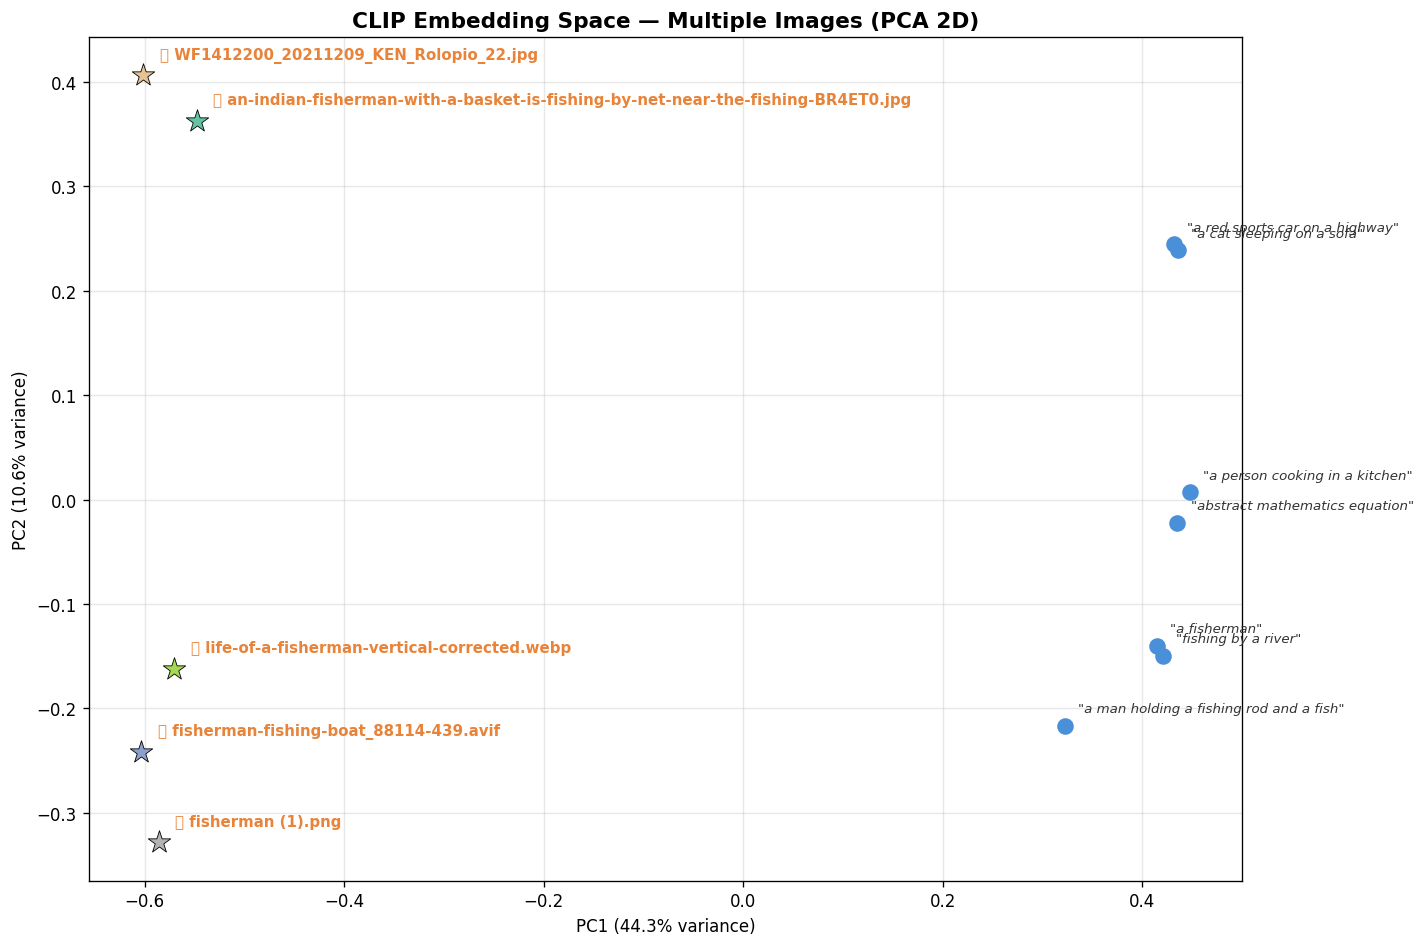


Plotted 7 texts + 5 images
Saved: embedding_space_multi.png


In [ ]:
# ── CELL 10: Upload more images and re-plot PCA ──────────────
# Run this cell each time you want to add images and see the
# updated embedding space. Upload as many .png or .webp files
# as you like when prompted.

from google.colab import files
from PIL import Image
import numpy as np
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams["figure.dpi"] = 120

# Upload images
print("Select one or more images (.png or .webp)...")
uploaded = files.upload()

# Generate embeddings for all uploaded images
image_embeddings = []
image_labels = []

for filename in uploaded.keys():
    img = Image.open(filename).convert("RGB")
    img_inputs = processor(images=img)
    pixel_vals = torch.FloatTensor(np.array(img_inputs["pixel_values"]))
    with torch.no_grad():
        img_feat = model.get_image_features(pixel_values=pixel_vals).pooler_output.detach()
        img_feat = img_feat / img_feat.norm(dim=-1, keepdim=True)
    image_embeddings.append(img_feat.squeeze().numpy())
    image_labels.append(filename)
    print(f"  ✅ Embedded: {filename}")

# Also include the original fisherman image
image_embeddings.append(image_embedding.squeeze().detach().numpy())
image_labels.append(IMAGE_PATH)

# Re-generate text embeddings
comparison_texts = [
    "a fisherman",
    "a man holding a fishing rod and a fish",
    "fishing by a river",
    "a person cooking in a kitchen",
    "a red sports car on a highway",
    "a cat sleeping on a sofa",
    "abstract mathematics equation",
]

text_embs = []
with torch.no_grad():
    for t in comparison_texts:
        t_inputs = tokenizer(t, return_tensors="pt", padding=True)
        t_feat = model.get_text_features(**t_inputs).pooler_output.detach()
        t_feat = t_feat / t_feat.norm(dim=-1, keepdim=True)
        text_embs.append(t_feat.squeeze().numpy())

# Stack everything: texts first, then images
all_embs = np.vstack(text_embs + image_embeddings)

# PCA to 2D
pca = PCA(n_components=2)
coords = pca.fit_transform(all_embs)

# Plot
fig, ax = plt.subplots(figsize=(12, 8))

# Text points
for i, label in enumerate(comparison_texts):
    ax.scatter(coords[i, 0], coords[i, 1], s=80, c="#4A90D9", zorder=3)
    ax.annotate(f'"{label}"', (coords[i, 0], coords[i, 1]),
                textcoords="offset points", xytext=(8, 8),
                fontsize=8, color="#333", style="italic")

# Image points
num_texts = len(comparison_texts)
colors = plt.cm.Set2(np.linspace(0, 1, len(image_labels)))

for i, (label, color) in enumerate(zip(image_labels, colors)):
    idx = num_texts + i
    ax.scatter(coords[idx, 0], coords[idx, 1], s=200, c=[color],
               marker="*", zorder=4, edgecolors="black", linewidths=0.5)
    ax.annotate(f"🖼️ {label}", (coords[idx, 0], coords[idx, 1]),
                textcoords="offset points", xytext=(10, 10),
                fontsize=9, fontweight="bold", color="#E8833A")

ax.set_title("CLIP Embedding Space — Multiple Images (PCA 2D)", fontsize=13, fontweight="bold")
ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)")
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("embedding_space_multi.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"\nPlotted {len(comparison_texts)} texts + {len(image_labels)} images")
print("Saved: embedding_space_multi.png")

In [ ]:
# ── CELL 11: Prompt ensembling to reduce bias ────────────────
# Instead of embedding a single text like "a fisherman", we
# embed MULTIPLE diverse descriptions and average them.
# This shifts the text embedding toward a more inclusive
# representation that isn't biased toward any one group.

import torch
import numpy as np
import torch.nn.functional as F

def get_ensemble_text_embedding(concept, model, tokenizer):
    """
    Create a debiased text embedding by averaging embeddings
    from multiple diverse prompts for the same concept.
    """
    # Diverse prompts for the same concept
    diverse_prompts = [
        f"a {concept}",
        f"a photo of a {concept}",
        f"an Indian {concept}",
        f"an African {concept}",
        f"an Asian {concept}",
        f"a European {concept}",
        f"a South American {concept}",
        f"a young {concept}",
        f"an old {concept}",
        f"a {concept} in traditional clothing",
        f"a {concept} in modern clothing",
    ]

    all_feats = []
    with torch.no_grad():
        for prompt in diverse_prompts:
            t_inputs = tokenizer(prompt, return_tensors="pt", padding=True)
            t_feat = model.get_text_features(**t_inputs).pooler_output.detach()
            t_feat = t_feat / t_feat.norm(dim=-1, keepdim=True)
            all_feats.append(t_feat)

    # Average all embeddings and re-normalize
    avg_embedding = torch.cat(all_feats, dim=0).mean(dim=0, keepdim=True)
    avg_embedding = avg_embedding / avg_embedding.norm(dim=-1, keepdim=True)

    return avg_embedding, diverse_prompts


# Compare: single prompt vs ensemble
single_inputs = tokenizer("a fisherman", return_tensors="pt", padding=True)
with torch.no_grad():
    single_emb = model.get_text_features(**single_inputs).pooler_output.detach()
    single_emb = single_emb / single_emb.norm(dim=-1, keepdim=True)

ensemble_emb, prompts_used = get_ensemble_text_embedding("fisherman", model, tokenizer)

print("=" * 60)
print("PROMPT ENSEMBLING — Bias Reduction")
print("=" * 60)
print(f"\nSingle prompt:  \"a fisherman\"")
print(f"Ensemble uses {len(prompts_used)} prompts:")
for p in prompts_used:
    print(f"  • \"{p}\"")

# Now compare both against your uploaded images
# Re-upload or reuse your images here
from google.colab import files as colab_files
from PIL import Image

print("\n\nUpload your fisherman images to compare...")
uploaded = colab_files.upload()

print(f"\n{'Image':<35} {'Single sim':>12} {'Ensemble sim':>14} {'Δ':>8}")
print("-" * 72)

for filename in uploaded.keys():
    img = Image.open(filename).convert("RGB")
    img_inputs = processor(images=img)
    pixel_vals = torch.FloatTensor(np.array(img_inputs["pixel_values"]))

    with torch.no_grad():
        img_feat = model.get_image_features(pixel_values=pixel_vals).pooler_output.detach()
        img_feat = img_feat / img_feat.norm(dim=-1, keepdim=True)

    sim_single   = F.cosine_similarity(single_emb, img_feat).item()
    sim_ensemble = F.cosine_similarity(ensemble_emb, img_feat).item()
    delta        = sim_ensemble - sim_single

    print(f"{filename:<35} {sim_single:>+12.4f} {sim_ensemble:>+14.4f} {delta:>+8.4f}")

print()
print("A positive Δ means the ensemble is MORE similar to that image")
print("than the single prompt. If your diverse fisherman images now")
print("score closer to each other, the bias is being reduced.")

PROMPT ENSEMBLING — Bias Reduction

Single prompt:  "a fisherman"
Ensemble uses 11 prompts:
  • "a fisherman"
  • "a photo of a fisherman"
  • "an Indian fisherman"
  • "an African fisherman"
  • "an Asian fisherman"
  • "a European fisherman"
  • "a South American fisherman"
  • "a young fisherman"
  • "an old fisherman"
  • "a fisherman in traditional clothing"
  • "a fisherman in modern clothing"


Upload your fisherman images to compare...


Saving an-indian-fisherman-with-a-basket-is-fishing-by-net-near-the-fishing-BR4ET0.jpg to an-indian-fisherman-with-a-basket-is-fishing-by-net-near-the-fishing-BR4ET0 (1).jpg
Saving fisherman-fishing-boat_88114-439.avif to fisherman-fishing-boat_88114-439 (1).avif
Saving life-of-a-fisherman-vertical-corrected.webp to life-of-a-fisherman-vertical-corrected (1).webp
Saving WF1412200_20211209_KEN_Rolopio_22.jpg to WF1412200_20211209_KEN_Rolopio_22 (1).jpg

Image                                 Single sim   Ensemble sim        Δ
------------------------------------------------------------------------
an-indian-fisherman-with-a-basket-is-fishing-by-net-near-the-fishing-BR4ET0 (1).jpg      +0.2862        +0.3157  +0.0295
fisherman-fishing-boat_88114-439 (1).avif      +0.2859        +0.2945  +0.0086
life-of-a-fisherman-vertical-corrected (1).webp      +0.2462        +0.2530  +0.0068
WF1412200_20211209_KEN_Rolopio_22 (1).jpg      +0.2217        +0.2414  +0.0197

A positive Δ means the ensemble 

In [ ]:
# ── CELL 12: Install fine-tuning dependencies ────────────────
!pip install -q peft datasets requests ddgs

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.5/45.5 kB 1.3 MB/s eta 0:00:00


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [ ]:
import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning, module=".*jupyter_client.*")
warnings.filterwarnings("ignore", category=DeprecationWarning, module=".*duckduckgo.*")
warnings.filterwarnings("ignore", category=DeprecationWarning)

# ── CELL 14: Download diverse fisherman images ───────────────
import os
import requests
import time
from ddgs import DDGS

BASE_DIR = "fisherman_dataset"
os.makedirs(BASE_DIR, exist_ok=True)

search_queries = [
    ("fisherman India",           "indian",         12),
    ("fisherman Brazil",          "brazilian",      12),
    ("fisherman Indonesia",       "indonesian",     12),
    ("fisherman Europe river",    "european",       12),
    ("fishing in China",          "chinese",        12),
    ("fishing in Arab countries", "middle_eastern", 12),
    ("African fishermen sea",     "african",        12),
    ("Japan fishing",             "japanese",       12),
    ("Mexico fishing",            "mexican",        12),
    ("Thailand fishing",          "thai",           12),
]

HEADERS = {
    "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36"
}

for query, subfolder, target_count in search_queries:
    save_dir = os.path.join(BASE_DIR, subfolder)
    os.makedirs(save_dir, exist_ok=True)

    existing = [f for f in os.listdir(save_dir) if f.lower().endswith(('.jpg', '.jpeg', '.png', '.webp', '.avif', '.bmp', '.tiff'))]
    if len(existing) >= target_count:
        print(f"  ✅ {subfolder}: already have {len(existing)} images, skipping")
        continue

    print(f"  ⬇️  Searching: \"{query}\"")

    try:
        with DDGS() as ddgs:
            results = list(ddgs.images(query, max_results=target_count + 5))
    except Exception as e:
        print(f"     ⚠️  Search failed: {e}")
        continue

    downloaded = 0
    for i, result in enumerate(results):
        if downloaded >= target_count:
            break

        url = result.get("image", "")
        if not url:
            continue

        ext = url.split(".")[-1].split("?")[0].lower()
        if ext not in ("jpg", "jpeg", "png", "webp", "avif", "bmp", "tiff"):
            ext = "jpg"
        fname = f"{subfolder}_{downloaded+1:03d}.{ext}"
        fpath = os.path.join(save_dir, fname)

        try:
            resp = requests.get(url, headers=HEADERS, timeout=10, stream=True)
            resp.raise_for_status()

            # Check it's actually an image
            content_type = resp.headers.get("content-type", "")
            if "image" not in content_type:
                continue

            with open(fpath, "wb") as f:
                for chunk in resp.iter_content(8192):
                    f.write(chunk)

            # Verify with PIL
            from PIL import Image
            img = Image.open(fpath).convert("RGB")
            if img.size[0] < 100 or img.size[1] < 100:
                os.remove(fpath)
                continue

            downloaded += 1

        except Exception:
            if os.path.exists(fpath):
                os.remove(fpath)
            continue

    print(f"     ✅ Got {downloaded} images → {save_dir}/")
    time.sleep(2)  # be polite between searches

    if downloaded == 0:
      time.sleep(5)  # extra wait after a failed category

# Summary
print("\n" + "=" * 60)
print("📁 DATASET SUMMARY")
print("=" * 60)
total = 0
for subfolder in sorted(os.listdir(BASE_DIR)):
    path = os.path.join(BASE_DIR, subfolder)
    if os.path.isdir(path):
        imgs = [f for f in os.listdir(path) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
        total += len(imgs)
        print(f"  {subfolder:<18} → {len(imgs)} images")
print(f"\n  TOTAL: {total} images")
print("All paired with label: \"a fisherman\"")

  ✅ indian: already have 12 images, skipping
  ✅ brazilian: already have 12 images, skipping
  ✅ indonesian: already have 12 images, skipping
  ✅ european: already have 12 images, skipping
  ✅ chinese: already have 12 images, skipping
  ✅ middle_eastern: already have 12 images, skipping
  ✅ african: already have 12 images, skipping
  ⬇️  Searching: "Japan fishing"
     ⚠️  Search failed: No results found.
  ⬇️  Searching: "Mexico fishing"
     ⚠️  Search failed: No results found.
  ⬇️  Searching: "Thailand fishing"
     ⚠️  Search failed: No results found.

📁 DATASET SUMMARY
  african            → 12 images
  brazilian          → 12 images
  chinese            → 12 images
  european           → 12 images
  indian             → 12 images
  indonesian         → 12 images
  japanese           → 10 images
  mexican            → 0 images
  middle_eastern     → 12 images
  thai               → 0 images

  TOTAL: 94 images
All paired with label: "a fisherman"


In [ ]:
# ── CELL 14: Fine-tune CLIP with LoRA ────────────────────────
# Trains adapter layers on top of the frozen CLIP model so that
# all downloaded fisherman images map closer to "a fisherman".

import torch
import numpy as np
from PIL import Image
from peft import LoraConfig, get_peft_model
from torch.optim import AdamW

# ── Step 1: Configure LoRA adapters ──
lora_config = LoraConfig(
    r=8,
    lora_alpha=16,
    target_modules=["q_proj", "v_proj"],
    lora_dropout=0.1,
    bias="none",
)

peft_model = get_peft_model(model, lora_config)
peft_model.train()

trainable, total = 0, 0
for p in peft_model.parameters():
    total += p.numel()
    if p.requires_grad:
        trainable += p.numel()
print(f"Trainable params: {trainable:,} / {total:,} ({100*trainable/total:.2f}%)")

# ── Step 2: Prepare training pairs ──
# Every image gets paired with the SAME text "a fisherman"
# This teaches the model that all these diverse images = fisherman
training_text = "a fisherman"
training_pairs = []

import os
BASE_DIR = "fisherman_dataset"
for subfolder in os.listdir(BASE_DIR):
    folder_path = os.path.join(BASE_DIR, subfolder)
    if not os.path.isdir(folder_path):
        continue
    for fname in os.listdir(folder_path):
        if fname.lower().endswith(('.jpg', '.jpeg', '.png', '.webp', '.avif', '.bmp', '.tiff')):
            img_path = os.path.join(folder_path, fname)
            try:
                img = Image.open(img_path).convert("RGB")
                training_pairs.append((img, training_text))
            except Exception as e:
                print(f"  ⚠️  Skipping {img_path}: {e}")

print(f"Training pairs: {len(training_pairs)}")

# ── Step 3: Training loop ──
optimizer = AdamW(
    filter(lambda p: p.requires_grad, peft_model.parameters()),
    lr=1e-4,
    weight_decay=0.01,
)

NUM_EPOCHS = 10
TEMPERATURE = 0.07  # CLIP's learned temperature (logit_scale)

print(f"\nTraining for {NUM_EPOCHS} epochs...\n")

for epoch in range(NUM_EPOCHS):
    epoch_loss = 0.0

    # Shuffle training order each epoch
    indices = np.random.permutation(len(training_pairs))

    for idx in indices:
        img, text = training_pairs[idx]

        # Process image
        img_inputs = processor(images=img)
        pixel_vals = torch.FloatTensor(np.array(img_inputs["pixel_values"]))

        # Process text
        txt_inputs = tokenizer(text, return_tensors="pt", padding=True)

        # Forward pass through both encoders
        image_features = peft_model.get_image_features(pixel_values=pixel_vals)
        text_features = peft_model.get_text_features(**txt_inputs)

        # Handle different return types
        if hasattr(image_features, "pooler_output"):
            image_features = image_features.pooler_output
        if hasattr(text_features, "pooler_output"):
            text_features = text_features.pooler_output

        # Normalize
        image_features = image_features / image_features.norm(dim=-1, keepdim=True)
        text_features = text_features / text_features.norm(dim=-1, keepdim=True)

        # Contrastive loss: push this image-text pair together
        # For a single pair, this simplifies to negative cosine similarity
        similarity = torch.cosine_similarity(image_features, text_features)
        loss = (1 - similarity).mean()

        loss.backward()
        optimizer.step()
        optimizer.zero_grad()

        epoch_loss += loss.item()

    avg_loss = epoch_loss / max(len(training_pairs), 1)
    bar = "█" * int((1 - avg_loss) * 40)
    print(f"  Epoch {epoch+1:>2}/{NUM_EPOCHS}  loss: {avg_loss:.4f}  {bar}")

print("\n✅ Fine-tuning complete!")

# Save the adapter
ADAPTER_PATH = "clip_debiased_lora"
peft_model.save_pretrained(ADAPTER_PATH)
print(f"Adapter saved to: ./{ADAPTER_PATH}/  (only a few MB)")

/usr/local/lib/python3.12/dist-packages/peft/mapping_func.py:72: UserWarning: You are trying to modify a model with PEFT for a second time. If you want to reload the model with a different config, make sure to call `.unload()` before.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/peft/tuners/tuners_utils.py:285: UserWarning: Already found a `peft_config` attribute in the model. This will lead to having multiple adapters in the model. Make sure to know what you are doing!
  warnings.warn(


Trainable params: 491,520 / 151,768,833 (0.32%)
Training pairs: 95

Training for 10 epochs...

  Epoch  1/10  loss: 0.5264  ██████████████████
  Epoch  2/10  loss: 0.0285  ██████████████████████████████████████
  Epoch  3/10  loss: 0.0050  ███████████████████████████████████████
  Epoch  4/10  loss: 0.0028  ███████████████████████████████████████
  Epoch  5/10  loss: 0.0018  ███████████████████████████████████████
  Epoch  6/10  loss: 0.0014  ███████████████████████████████████████
  Epoch  7/10  loss: 0.0012  ███████████████████████████████████████
  Epoch  8/10  loss: 0.0010  ███████████████████████████████████████
  Epoch  9/10  loss: 0.0008  ███████████████████████████████████████
  Epoch 10/10  loss: 0.0008  ███████████████████████████████████████

✅ Fine-tuning complete!
Adapter saved to: ./clip_debiased_lora/  (only a few MB)


Upload your test images (the same ones you tested before)...


Saving an-indian-fisherman-with-a-basket-is-fishing-by-net-near-the-fishing-BR4ET0.jpg to an-indian-fisherman-with-a-basket-is-fishing-by-net-near-the-fishing-BR4ET0 (2).jpg
Saving fisherman-fishing-boat_88114-439.avif to fisherman-fishing-boat_88114-439 (2).avif
Saving life-of-a-fisherman-vertical-corrected.webp to life-of-a-fisherman-vertical-corrected (2).webp
Saving WF1412200_20211209_KEN_Rolopio_22.jpg to WF1412200_20211209_KEN_Rolopio_22 (2).jpg

📊 BEFORE vs AFTER Fine-Tuning — Similarity to "a fisherman"
Image                                   Before      After        Δ     Change
------------------------------------------------------------------------
an-indian-fisherman-with-a-basket-is-fishing-by-net-near-the-fishing-BR4ET0 (2).jpg    +0.9995    +0.9995  +0.0000    ➡️ same
fisherman-fishing-boat_88114-439 (2).avif    +0.9984    +0.9984  +0.0000    ➡️ same
life-of-a-fisherman-vertical-corrected (2).webp    +0.9993    +0.9993  +0.0000    ➡️ same
WF1412200_20211209_KEN_Rolopio_2

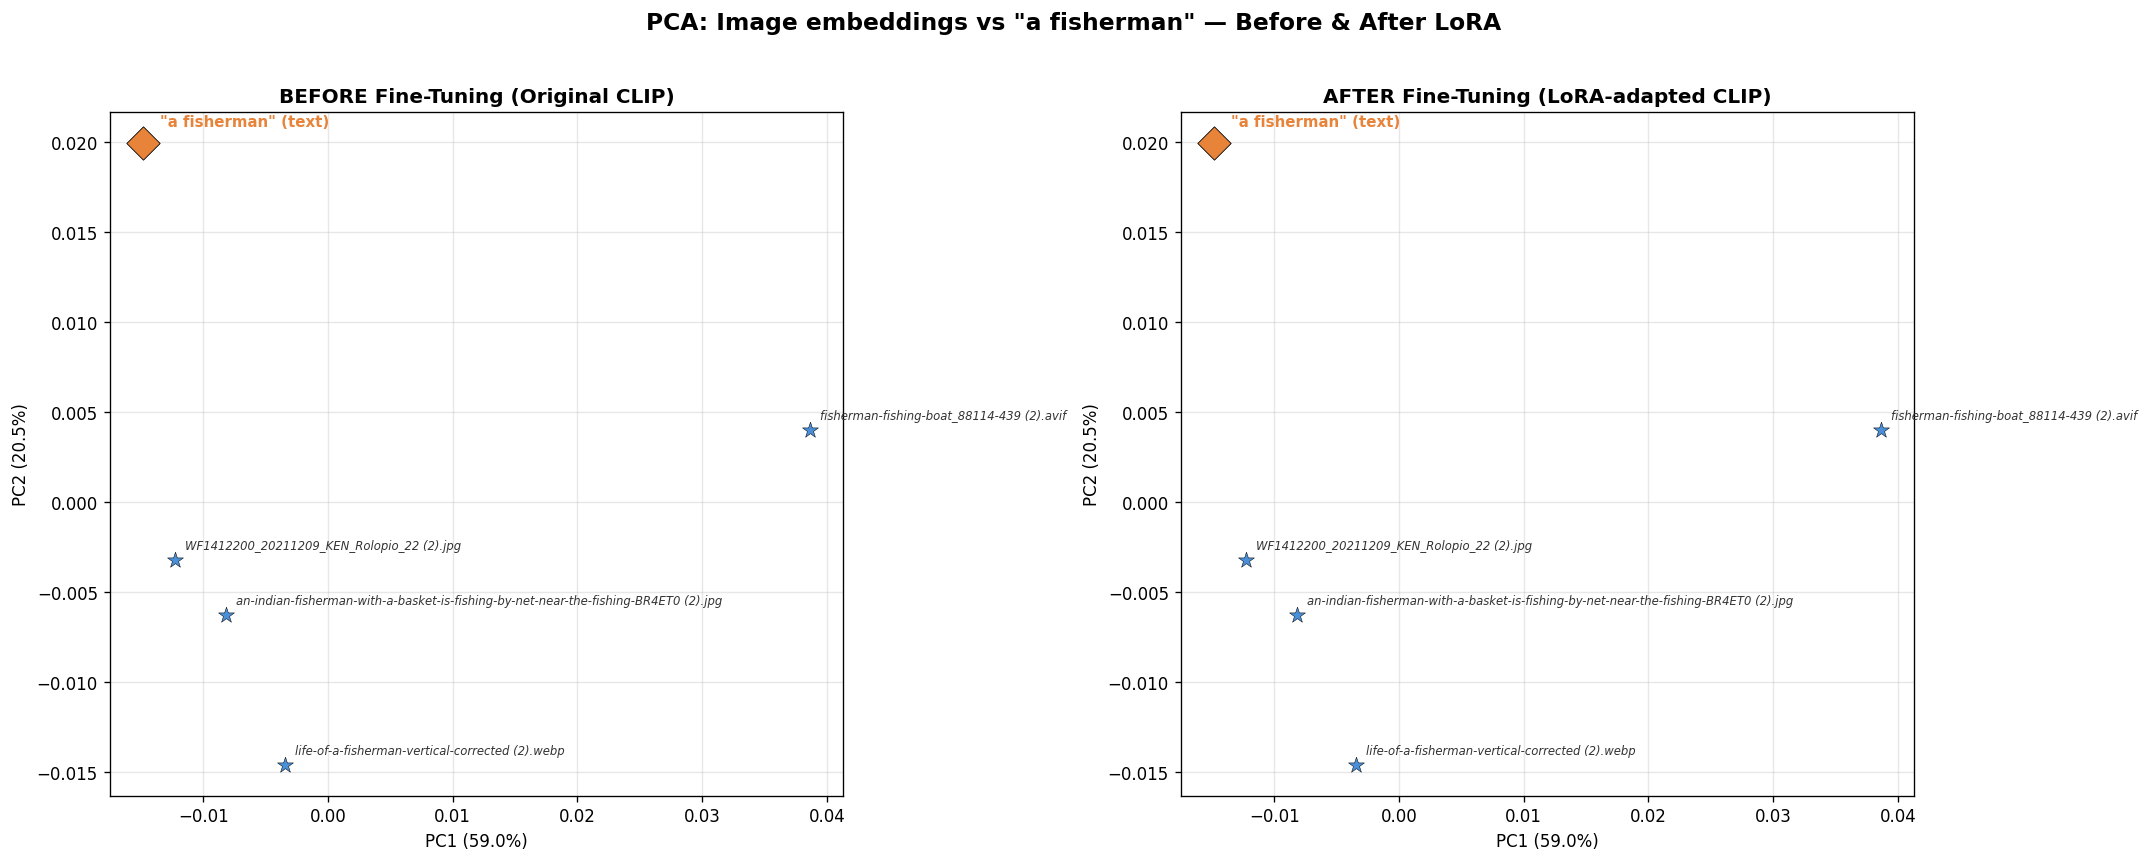


Saved: before_after_lora.png

In the AFTER plot, image points should be tighter / more
evenly distributed around the text point, showing reduced bias.


In [ ]:
# ── CELL 15: Test fine-tuned model and compare ───────────────
# Uses the single prompt "a fisherman" on the NEW model,
# asks you to upload images, and plots PCA comparison.

import torch.nn.functional as F
from sklearn.decomposition import PCA
from google.colab import files as colab_files
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams["figure.dpi"] = 120

peft_model.eval()

# ── Embed "a fisherman" with both old and new model ──
single_text = "a fisherman"
txt_inputs = tokenizer(single_text, return_tensors="pt", padding=True)

with torch.no_grad():
    # Original model
    old_text_feat = model.get_text_features(**txt_inputs)
    if hasattr(old_text_feat, "pooler_output"):
        old_text_feat = old_text_feat.pooler_output
    old_text_feat = old_text_feat / old_text_feat.norm(dim=-1, keepdim=True)

    # Fine-tuned model
    new_text_feat = peft_model.get_text_features(**txt_inputs)
    if hasattr(new_text_feat, "pooler_output"):
        new_text_feat = new_text_feat.pooler_output
    new_text_feat = new_text_feat / new_text_feat.norm(dim=-1, keepdim=True)

# ── Upload test images ──
print("Upload your test images (the same ones you tested before)...")
uploaded = colab_files.upload()

# ── Compute embeddings for all uploaded images on BOTH models ──
test_results = []

for filename in uploaded.keys():
    img = Image.open(filename).convert("RGB")
    img_inputs = processor(images=img)
    pixel_vals = torch.FloatTensor(np.array(img_inputs["pixel_values"]))

    with torch.no_grad():
        # Old model
        old_img_feat = model.get_image_features(pixel_values=pixel_vals)
        if hasattr(old_img_feat, "pooler_output"):
            old_img_feat = old_img_feat.pooler_output
        old_img_feat = old_img_feat / old_img_feat.norm(dim=-1, keepdim=True)

        # New model
        new_img_feat = peft_model.get_image_features(pixel_values=pixel_vals)
        if hasattr(new_img_feat, "pooler_output"):
            new_img_feat = new_img_feat.pooler_output
        new_img_feat = new_img_feat / new_img_feat.norm(dim=-1, keepdim=True)

    old_sim = F.cosine_similarity(old_text_feat, old_img_feat).item()
    new_sim = F.cosine_similarity(new_text_feat, new_img_feat).item()

    test_results.append({
        "filename": filename,
        "old_sim": old_sim,
        "new_sim": new_sim,
        "old_img_emb": old_img_feat.squeeze().detach().numpy(),
        "new_img_emb": new_img_feat.squeeze().detach().numpy(),
    })

# ── Print comparison table ──
print("\n" + "=" * 72)
print("📊 BEFORE vs AFTER Fine-Tuning — Similarity to \"a fisherman\"")
print("=" * 72)
print(f"{'Image':<35} {'Before':>10} {'After':>10} {'Δ':>8} {'Change':>10}")
print("-" * 72)

for r in test_results:
    delta = r["new_sim"] - r["old_sim"]
    arrow = "⬆️ better" if delta > 0.01 else ("⬇️ worse" if delta < -0.01 else "➡️ same")
    print(f"{r['filename']:<35} {r['old_sim']:>+10.4f} {r['new_sim']:>+10.4f} {delta:>+8.4f} {arrow:>10}")

# ── Compute spread (std dev of similarities) ──
old_sims = [r["old_sim"] for r in test_results]
new_sims = [r["new_sim"] for r in test_results]
print(f"\n{'Std dev of similarities:':<35} {np.std(old_sims):>10.4f} {np.std(new_sims):>10.4f}")
print("(Lower std dev = less bias — images are treated more equally)")

# ── PCA plot: side-by-side comparison ──
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))

for ax, title, text_emb, emb_key in [
    (ax1, "BEFORE Fine-Tuning (Original CLIP)", old_text_feat, "old_img_emb"),
    (ax2, "AFTER Fine-Tuning (LoRA-adapted CLIP)", new_text_feat, "new_img_emb"),
]:
    # Collect embeddings
    all_embs = [text_emb.squeeze().detach().numpy()]
    all_labels = ['"a fisherman" (text)']
    all_types = ["text"]

    for r in test_results:
        all_embs.append(r[emb_key])
        all_labels.append(r["filename"])
        all_types.append("image")

    all_embs = np.vstack(all_embs)

    # PCA
    pca = PCA(n_components=2)
    coords = pca.fit_transform(all_embs)

    # Plot text point
    ax.scatter(coords[0, 0], coords[0, 1], s=200, c="#E8833A",
               marker="D", zorder=4, edgecolors="black", linewidths=0.5)
    ax.annotate(all_labels[0], (coords[0, 0], coords[0, 1]),
                textcoords="offset points", xytext=(10, 10),
                fontsize=9, fontweight="bold", color="#E8833A")

    # Plot image points
    for i in range(1, len(all_labels)):
        ax.scatter(coords[i, 0], coords[i, 1], s=100, c="#4A90D9",
                   marker="*", zorder=3, edgecolors="black", linewidths=0.3)
        ax.annotate(all_labels[i], (coords[i, 0], coords[i, 1]),
                    textcoords="offset points", xytext=(6, 6),
                    fontsize=7, color="#333", style="italic")

    ax.set_title(title, fontsize=12, fontweight="bold")
    ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)")
    ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)")
    ax.grid(True, alpha=0.3)

plt.suptitle('PCA: Image embeddings vs "a fisherman" — Before & After LoRA',
             fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("before_after_lora.png", dpi=150, bbox_inches="tight")
plt.show()

print("\nSaved: before_after_lora.png")
print("\nIn the AFTER plot, image points should be tighter / more")
print("evenly distributed around the text point, showing reduced bias.")